# Step 1: Data Understanding & Preprocessing
**FreshGuard ML Pipeline — Sell-Through Probability Prediction Before Expiry**

At this stage we do **not** make predictions. We only understand and prepare clean data.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)

DATA_PATH = r'C:/Users/ASUS/OneDrive/Desktop/synthetic_expiry_risk_dataset.csv'
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (100000, 54)


,record_id,product_id,product_name,category,store_id,region,supplier_id,transaction_date,expiration_date,shelf_life_days,...,expiry_risk_prob,expire_before_sold,category_waste_pct,category_waste_prob,sales_category,sales_avg_quantity,sales_avg_unit_price,sales_avg_discount_amount,sales_total_quantity,sales_count_transactions
0,1,BAK_DON_743,Donuts,Bakery,STORE_046,West,SUPPLIER_03,25 09 2024,29 09 2024,4,...,0.523132,1,15.345413,0.153454,Bakery,2.890110,15.852802,4.132527,526,182
1,2,MEA_SAU_338,Sausages,Meat,STORE_030,Southwest,SUPPLIER_12,14 04 2023,21 04 2023,9,...,0.560162,1,18.203968,0.182040,Meat_Seafood,3.049689,15.518944,4.472422,491,161
2,3,BAK_BAG_799,Bagels,Bakery,STORE_035,Midwest,SUPPLIER_08,25 10 2024,27 10 2024,2,...,0.536416,1,15.345413,0.153454,Bakery,2.890110,15.852802,4.132527,526,182


## 1.1 Data Sources

| Source | Key Columns | Answers |
|---|---|---|
| **Inventory** | `product_id`, `initial_quantity`, `expiration_date`, `shelf_life_days` | What stock exists and when it expires |
| **Sales** | `units_sold`, `daily_demand`, `time_to_sell` | How fast products are selling |

**Target:** `expire_before_sold` (1 = expired before selling, 0 = sold before expiry)

In [13]:
print('=== All Columns ===')
for i, col in enumerate(df.columns.tolist(), 1):
    print(f'  {i:2}. {col}')

=== All Columns ===
   1. record_id
   2. product_id
   3. product_name
   4. category
   5. store_id
   6. region
   7. supplier_id
   8. transaction_date
   9. expiration_date
  10. shelf_life_days
  11. days_remaining_at_purchase
  12. storage_temp
  13. temp_deviation
  14. base_price
  15. cost_price
  16. initial_quantity
  17. spoilage_sensitivity
  18. day_of_week
  19. is_weekend
  20. month
  21. daily_demand
  22. demand_variability
  23. temp_abuse_events
  24. distribution_hours
  25. handling_score
  26. packaging_score
  27. spoilage_risk
  28. was_spoiled
  29. quality_grade
  30. days_until_expiry
  31. markdown_applied
  32. discount_pct
  33. selling_price
  34. units_sold
  35. units_wasted
  36. waste_pct
  37. revenue
  38. waste_cost
  39. profit
  40. profit_margin_pct
  41. supplier_score
  42. is_promoted
  43. time_to_sell
  44. diff
  45. expiry_risk_prob
  46. expire_before_sold
  47. category_waste_pct
  48. category_waste_prob
  49. sales_category
  50. s

In [14]:
print('=== Data Types ===')
print(df.dtypes)
print(f'\nTotal rows: {len(df)}')

=== Data Types ===
record_id                       int64
product_id                     object
product_name                   object
category                       object
store_id                       object
region                         object
supplier_id                    object
transaction_date               object
expiration_date                object
shelf_life_days                 int64
days_remaining_at_purchase      int64
storage_temp                  float64
temp_deviation                float64
base_price                    float64
cost_price                    float64
initial_quantity                int64
spoilage_sensitivity          float64
day_of_week                     int64
is_weekend                      int64
month                           int64
daily_demand                    int64
demand_variability            float64
temp_abuse_events               int64
distribution_hours            float64
handling_score                  int64
packaging_score                

In [15]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print('=== Missing Values ===')
print('None found!' if len(missing) == 0 else missing)

=== Missing Values ===
None found!


In [16]:
dups = df.duplicated().sum()
print(f'Duplicate rows: {dups}')
if dups > 0:
    df = df.drop_duplicates()
    print(f'Removed {dups} duplicates. New shape: {df.shape}')

Duplicate rows: 0


=== Target Variable Distribution ===
expire_before_sold
1    56526
0    43474
Name: count, dtype: int64

expire_before_sold
1    0.565
0    0.435
Name: proportion, dtype: float64


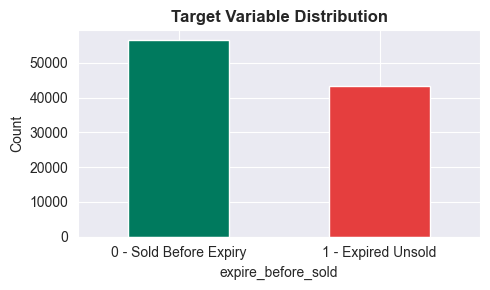

In [17]:
print('=== Target Variable Distribution ===')
print(df['expire_before_sold'].value_counts())
print()
print(df['expire_before_sold'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(5, 3))
df['expire_before_sold'].value_counts().plot(
    kind='bar', ax=ax, color=['#007A5E','#E53E3E'], edgecolor='white', width=0.5)
ax.set_xticklabels(['0 - Sold Before Expiry','1 - Expired Unsold'], rotation=0)
ax.set_title('Target Variable Distribution', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('outputs/target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
df.describe().round(2)

,record_id,shelf_life_days,days_remaining_at_purchase,storage_temp,temp_deviation,base_price,cost_price,initial_quantity,spoilage_sensitivity,day_of_week,...,diff,expiry_risk_prob,expire_before_sold,category_waste_pct,category_waste_prob,sales_avg_quantity,sales_avg_unit_price,sales_avg_discount_amount,sales_total_quantity,sales_count_transactions
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.0,...,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,50000.50,67.17,56.11,3.13,1.60,36.41,20.06,254.85,0.69,3.0,...,inf,0.52,0.57,22.59,0.23,2.99,15.45,4.47,635.93,213.02
std,28867.66,140.55,118.16,9.50,1.21,87.42,48.89,141.69,0.22,2.0,...,NaN,0.23,0.50,11.04,0.11,0.09,0.46,0.25,246.79,83.55
min,1.00,1.00,0.00,-27.70,0.00,1.00,0.41,10.00,0.30,0.0,...,-712.00,0.00,0.00,14.56,0.15,2.79,14.34,4.13,475.00,160.00
25%,25000.75,5.00,4.00,1.10,0.60,6.27,3.36,132.00,0.50,1.0,...,-1.54,0.46,0.00,16.90,0.17,2.96,15.27,4.25,491.00,161.00
50%,50000.50,9.00,8.00,4.00,1.40,10.22,5.58,255.00,0.75,3.0,...,0.45,0.51,1.00,17.80,0.18,2.99,15.52,4.47,524.00,182.00
75%,75000.25,24.00,20.00,6.60,2.30,17.01,9.50,377.00,0.90,5.0,...,2.16,0.55,1.00,20.70,0.21,3.05,15.73,4.76,600.00,195.00
max,100000.00,730.00,723.00,27.70,9.00,499.98,346.61,500.00,0.95,6.0,...,inf,1.00,1.00,50.01,0.50,3.09,16.08,4.89,1135.00,380.00


In [19]:
print('=== Product Categories ===')
print(df['category'].value_counts())
print()
cat_risk = df.groupby('category')['expire_before_sold'].mean().sort_values(ascending=False)
print('=== Average Expiry Risk by Category ===')
print(cat_risk.round(3))

=== Product Categories ===
category
Pharmaceuticals    10120
Meat               10055
Ready_to_Eat       10049
Bakery             10039
Produce            10001
Deli                9991
Dairy               9964
Seafood             9957
Frozen_Meals        9923
Beverages           9901
Name: count, dtype: int64

=== Average Expiry Risk by Category ===
category
Ready_to_Eat       0.727
Seafood            0.650
Frozen_Meals       0.643
Bakery             0.619
Meat               0.565
Beverages          0.538
Produce            0.528
Deli               0.506
Pharmaceuticals    0.440
Dairy              0.435
Name: expire_before_sold, dtype: float64


In [20]:
df['transaction_date'] = pd.to_datetime(df['transaction_date'], dayfirst=True, errors='coerce')
df['expiration_date']  = pd.to_datetime(df['expiration_date'],  dayfirst=True, errors='coerce')
print('Date parsing complete.')
print(f"Transaction date range: {df['transaction_date'].min().date()} to {df['transaction_date'].max().date()}")
print(f"Expiration date range:  {df['expiration_date'].min().date()} to {df['expiration_date'].max().date()}")

Date parsing complete.
Transaction date range: 2023-01-01 to 2024-12-31
Expiration date range:  2023-01-01 to 2026-11-30


In [21]:
inf_cols = [c for c in df.select_dtypes(include=[np.number]).columns if np.isinf(df[c]).any()]
print(f'Columns with inf values: {inf_cols}')
for col in inf_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)
    med = df[col].median()
    df[col].fillna(med, inplace=True)
    print(f'  {col}: inf replaced with median ({med:.2f})')

Columns with inf values: ['time_to_sell', 'diff']
  time_to_sell: inf replaced with median (5.29)
  diff: inf replaced with median (0.20)


In [22]:
df.to_csv('outputs/cleaned_dataset.csv', index=False)
print(f'Saved outputs/cleaned_dataset.csv  Shape: {df.shape}')

Saved outputs/cleaned_dataset.csv  Shape: (100000, 54)


## Summary
- Loaded dataset, identified inventory and sales feature groups.
- Removed duplicates, handled infinity values, parsed dates.
- Target: `expire_before_sold` (binary classification).

**Next: Step2_Feature_Engineering.ipynb**